<a href="https://colab.research.google.com/github/shivasivangi/mlproject/blob/main/sales_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
data = """OrderID,OrderDate,Product,Category,Region,Sales,Quantity,Profit
1001,2023-01-05,Laptop,Technology,East,85000,2,12000
1002,2023-01-07,Mobile Phone,Technology,West,45000,3,8000
1003,2023-01-10,Office Chair,Furniture,North,12000,4,2500
1004,2023-01-15,Printer,Technology,South,22000,1,3000
1005,2023-02-02,Table,Furniture,East,18000,2,4000
1006,2023-02-05,Headphones,Technology,West,9000,5,1500
1007,2023-02-10,Notebook,Stationery,North,3000,10,800
1008,2023-02-15,Pen Set,Stationery,South,1500,15,400
1009,2023-03-01,Desktop Computer,Technology,East,65000,1,10000
1010,2023-03-05,Bookshelf,Furniture,West,25000,1,6000
1011,2023-03-10,Monitor,Technology,North,18000,2,3500
1012,2023-03-15,Mouse,Technology,South,4000,6,700
1013,2023-04-02,Keyboard,Technology,East,6000,4,1200
1014,2023-04-05,Office Desk,Furniture,West,32000,1,7500
1015,2023-04-10,Stapler,Stationery,North,1200,8,300
1016,2023-05-01,Tablet,Technology,South,30000,2,5000
1017,2023-05-05,Filing Cabinet,Furniture,East,28000,1,6500
1018,2023-05-10,Calculator,Stationery,West,2500,5,600
1019,2023-06-01,Smart Watch,Technology,North,15000,2,2500
1020,2023-06-05,Office Lamp,Furniture,South,8000,2,1800
"""

with open("sales.csv", "w") as f:
    f.write(data)

print("sales.csv created successfully!")


sales.csv created successfully!


In [2]:
import os
os.listdir()


['.config', 'sales.csv', 'sample_data']

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [4]:
df = pd.read_csv("sales.csv")
df.head()


,OrderID,OrderDate,Product,Category,Region,Sales,Quantity,Profit
0,1001,2023-01-05,Laptop,Technology,East,85000,2,12000
1,1002,2023-01-07,Mobile Phone,Technology,West,45000,3,8000
2,1003,2023-01-10,Office Chair,Furniture,North,12000,4,2500
3,1004,2023-01-15,Printer,Technology,South,22000,1,3000
4,1005,2023-02-02,Table,Furniture,East,18000,2,4000


In [5]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   OrderID    20 non-null     int64 
 1   OrderDate  20 non-null     object
 2   Product    20 non-null     object
 3   Category   20 non-null     object
 4   Region     20 non-null     object
 5   Sales      20 non-null     int64 
 6   Quantity   20 non-null     int64 
 7   Profit     20 non-null     int64 
dtypes: int64(4), object(4)
memory usage: 1.4+ KB


In [6]:
df.isnull().sum()


,0
OrderID,0
OrderDate,0
Product,0
Category,0
Region,0
Sales,0
Quantity,0
Profit,0


In [7]:
df.drop_duplicates(inplace=True)


In [8]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])


In [9]:
df.describe()
df["Category"].value_counts()
df["Region"].value_counts()


,count
Region,
East,5
West,5
North,5
South,5


In [10]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)


Total Sales: 430200
Total Profit: 77800


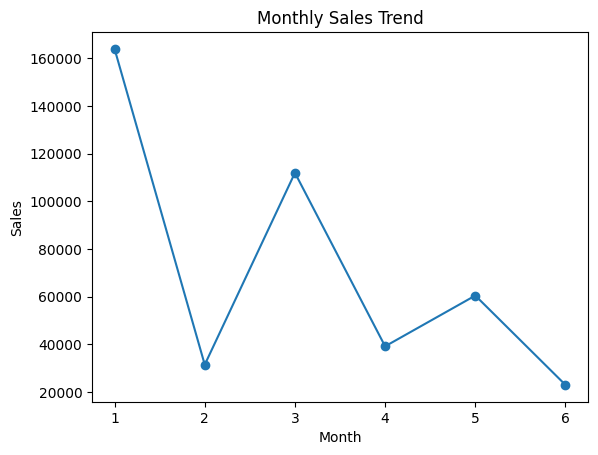

In [11]:
monthly_sales = df.groupby(df["OrderDate"].dt.month)["Sales"].sum()

plt.figure()
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


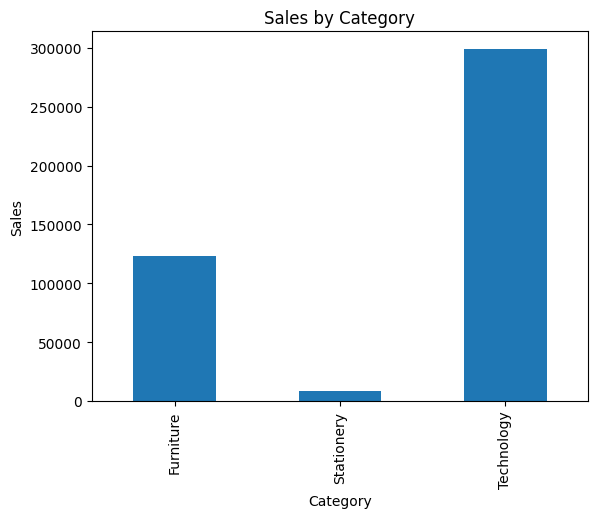

In [12]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure()
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()


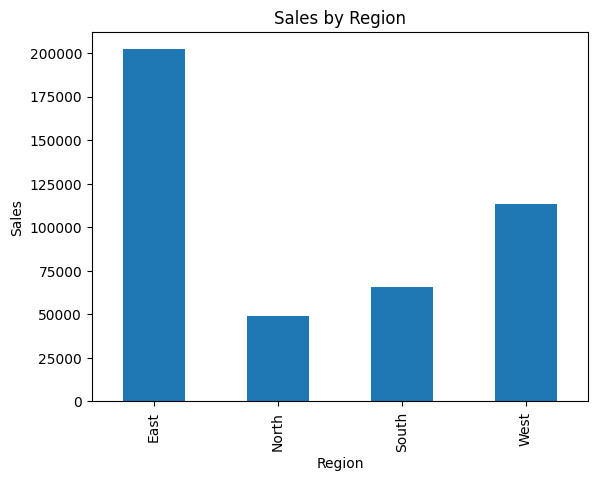

In [13]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure()
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()


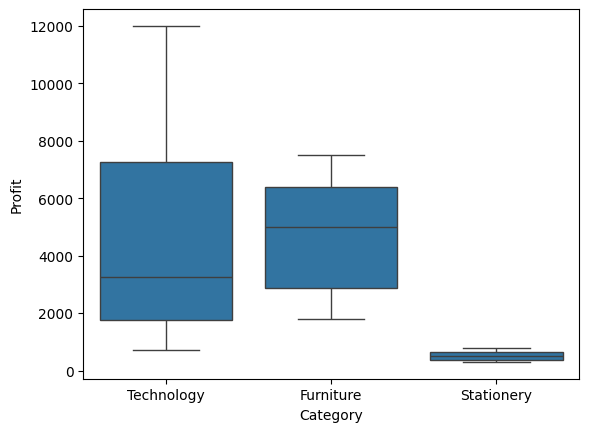

In [14]:
sns.boxplot(x="Category", y="Profit", data=df)
plt.show()


In [15]:
top_products = df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(10)
top_products


,Sales
Product,
Laptop,85000
Desktop Computer,65000
Mobile Phone,45000
Office Desk,32000
Tablet,30000
Filing Cabinet,28000
Bookshelf,25000
Printer,22000
Monitor,18000


In [16]:
df.to_csv("cleaned_sales.csv", index=False)


In [17]:
from google.colab import files
files.download("cleaned_sales.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>